In [ ]:
"""
test_ca_tools.py

A full regression test for ca_tools.py. It checks every stage ,
prints PASS/FAIL for each one with the numbers involved, and finishes with a
summary count. It does NOT stop on the first failure  it keeps going so you
get one complete report.
"""

import numpy as np
from ca_tools import get_neighbours, decide_new_state, run_ca, summarize_stability

passed = 0
failed = 0

def check(name, condition, detail=""):
    global passed, failed
    if condition:
        passed += 1
        print(f"[PASS] {name}")
    else:
        failed += 1
        print(f"[FAIL] {name}  -  {detail}")


print("=" * 60)
print("GET_NEIGHBOURS")
print("=" * 60)

test_grid = np.array([
    [0, 1, 2],
    [1, 1, 0],
    [2, 0, 1]
])

values, weights = get_neighbours(test_grid, 1, 1)
check("von Neumann centre cell", sorted(values) == [0, 0, 1, 1], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 1, 1, neighbourhood='moore')
check("Moore centre cell", sorted(values) == [0, 0, 0, 1, 1, 1, 2, 2], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 0, 0)
check("fixed boundary, corner (0,0)", sorted(values) == [1, 1], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 2, 2)
check("fixed boundary, corner (2,2)", sorted(values) == [0, 0], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 0, 0, boundary='periodic')
check("periodic boundary, corner (0,0)", sorted(values) == [1, 1, 2, 2], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 1, 0, boundary='reflective')
check("reflective boundary, edge (1,0)", sorted(values) == [0, 1, 1, 2], f"got {sorted(values)}")

big_grid = np.arange(25).reshape(5, 5) % 3
values, weights = get_neighbours(big_grid, 2, 2, neighbourhood='von_neumann', radius=2)
check("radius=2 von Neumann count", len(values) == 12, f"got {len(values)}")

values, weights = get_neighbours(big_grid, 2, 2, neighbourhood='moore', radius=2)
check("radius=2 Moore count", len(values) == 24, f"got {len(values)}")

values, weights = get_neighbours(test_grid, 1, 1, neighbourhood='moore', direct_weight=2, diagonal_weight=1)
direct_weights_correct = all(w == 2 for v, w in zip(values, weights) if v in [test_grid[0,1], test_grid[2,1], test_grid[1,0], test_grid[1,2]])
check("direct/diagonal weighting produced weights", set(weights) == {1, 2}, f"got weights {weights}")


print()
print("=" * 60)
print("DECIDE_NEW_STATE")
print("=" * 60)

result = decide_new_state([1, 1, 1, 0], current_state=0, threshold=1)
check("majority rule flips on clear majority", result == 1, f"got {result}")

result = decide_new_state([1, 1, 0, 0], current_state=0, threshold=2)
check("majority rule stays on a tie", result == 0, f"got {result}")

result = decide_new_state([1, 1, 0, 0], current_state=0, threshold=3, neighbour_weights=[2, 2, 1, 1])
check("weighted counting breaks a tie", result == 1, f"got {result}")

result = decide_new_state([0, 0, 0, 1], current_state=1, threshold={0: 1, 1: 3, 2: 1})
check("per-type threshold protects a resistant type", result == 1, f"got {result}")

result = decide_new_state([0, 0, 0, 1], current_state=2, threshold={0: 1, 1: 3, 2: 1})
check("per-type threshold lets a weak type flip", result == 0, f"got {result}")

matrix = np.array([[0, 0, 5], [0, 0, 10], [5, 10, 0]])
result = decide_new_state([1, 1, 1, 2], current_state=0, rule='probabilistic',
                           interaction_matrix=matrix, temperature=0)
check("probabilistic rule refuses unfavourable flip at temperature=0", result == 0, f"got {result}")

rng = np.random.default_rng(0)
switch_count = sum(
    decide_new_state([1, 1, 1, 2], current_state=0, rule='probabilistic',
                      interaction_matrix=matrix, temperature=10, rng=rng) == 1
    for _ in range(1000)
)
switch_rate = switch_count / 1000
check("probabilistic rule switch rate near exp(-0.5)=0.6065", abs(switch_rate - 0.6065) < 0.07, f"got {switch_rate}")


print()
print("=" * 60)
print("RUN_CA")
print("=" * 60)

rng = np.random.default_rng(0)
test_map = rng.integers(0, 3, size=(10, 10))

result, snaps, history = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1)
check("run_ca returns 3 values (map, snapshots, history)", True)
check("history has one entry per generation", len(history) == 5, f"got {len(history)}")
check("snapshot saved at checkpoint", 5 in snaps, f"keys: {list(snaps.keys())}")

result_sync, _, _ = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, update_scheme='synchronous')
result_async, _, _ = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, update_scheme='asynchronous')
check("sync and async give different results", not np.array_equal(result_sync, result_async))

locked = np.zeros((10, 10), dtype=bool)
locked[0:3, 0:3] = True
before = test_map.copy()
result_locked, _, _ = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, locked_mask=locked)
check("locked region is unchanged", np.array_equal(result_locked[0:3, 0:3], before[0:3, 0:3]))
check("unlocked region did change", not np.array_equal(result_locked, before))

uniform_grid = np.zeros((10, 10), dtype=int)
result_no_nuc, _, _ = run_ca(uniform_grid.copy(), generations=5, checkpoints=[5], threshold=100)
check("no nucleation means no change with impossible threshold", (result_no_nuc != 0).sum() == 0,
      f"got {(result_no_nuc != 0).sum()} changed cells")

result_nuc, _, _ = run_ca(uniform_grid.copy(), generations=1, checkpoints=[1], threshold=100, nucleation_rate=0.3)
nuc_changed = (result_nuc != 0).sum()
check("nucleation causes some change with impossible threshold", nuc_changed > 0, f"got {nuc_changed} changed cells")

result_a, _, _ = run_ca(test_map.copy(), generations=10, checkpoints=[10], threshold=1)
target = {0: 1/3, 1: 1/3, 2: 1/3}
result_b, _, _ = run_ca(test_map.copy(), generations=10, checkpoints=[10], threshold=1,
                         target_proportions=target, conservation_strength=0.3)
check("conservation feedback runs without error and returns a valid map", result_b.shape == test_map.shape)

result_c, snaps_c, history_c = run_ca(test_map.copy(), generations=15, checkpoints=[15], threshold=1)
check("history is long enough for stability check", len(history_c) >= 6)


print()
print("=" * 60)
print("SUMMARIZE_STABILITY")
print("=" * 60)

summarize_stability(history_c, window=5, tolerance=1.0)
check("summarize_stability ran without error", True)


print()
print("=" * 60)
print(f"SUMMARY: {passed} passed, {failed} failed")
print("=" * 60)

In [1]:
from karnaugh_tools import encode_neighbourhood
import numpy as np

grid = np.array([
    [0, 1, 2],
    [1, 0, 1],
    [2, 1, 0]
])

print(encode_neighbourhood(grid, 1, 1))  # should print 40

40


In [2]:
from karnaugh_tools import encode_neighbourhood, build_table
import numpy as np

# a simple PGS-like input field
pgs = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 1, 2]
])

# a corresponding target field
target = np.array([
    [0, 1, 1],
    [1, 1, 2],
    [1, 2, 2]
])

table = build_table([(pgs, target)])

# print only the rows that actually got observations
for pattern_id in range(81):
    if table[pattern_id].sum() > 0:
        print(f"pattern {pattern_id:2d}: P(Mat1)={table[pattern_id,0]:.2f}  P(Mat2)={table[pattern_id,1]:.2f}  P(Mat3)={table[pattern_id,2]:.2f}")

pattern  0: P(Mat1)=1.00  P(Mat2)=0.00  P(Mat3)=0.00
pattern  3: P(Mat1)=0.00  P(Mat2)=1.00  P(Mat3)=0.00
pattern  9: P(Mat1)=0.00  P(Mat2)=1.00  P(Mat3)=0.00
pattern 12: P(Mat1)=0.00  P(Mat2)=1.00  P(Mat3)=0.00
pattern 28: P(Mat1)=0.00  P(Mat2)=0.00  P(Mat3)=1.00
pattern 34: P(Mat1)=0.00  P(Mat2)=0.00  P(Mat3)=1.00
pattern 46: P(Mat1)=0.00  P(Mat2)=0.00  P(Mat3)=1.00


In [3]:
from karnaugh_tools import encode_neighbourhood, build_table, apply_table

result = apply_table(pgs, table, rng=np.random.default_rng(42))
print("Input PGS:")
print(pgs)
print("\nGenerated output:")
print(result)
print("\nTarget was:")
print(target)

Input PGS:
[[0 0 1]
 [0 1 1]
 [1 1 2]]

Generated output:
[[0 1 1]
 [1 1 2]
 [1 2 2]]

Target was:
[[0 1 1]
 [1 1 2]
 [1 2 2]]


In [4]:
import sys
sys.path.insert(0, '.')
from pgs_tools import make_gaussian_fields, make_lithotype_map

# generate 20 pairs: input field A, target field B (different length scales)
pairs = []
for seed in range(50):
    f1, f2 = make_gaussian_fields(grid_size=50, len_scale_1=[20,20], seed_1=seed, seed_2=seed+100)
    
    pgs_field    = make_lithotype_map(f1, f2, Mat1=0.33, Mat2=0.34, Mat3=0.33)
    target_field = make_lithotype_map(f1, f2, Mat1=0.20, Mat2=0.50, Mat3=0.30)

    pairs.append((pgs_field, target_field))

table = build_table(pairs)
result = apply_table(pairs[0][0], table, rng=np.random.default_rng(42))

print("How many of the 81 patterns have observations:", (table.sum(axis=1) > 0).sum())
print("\nFirst 5 observed patterns:")
for i in range(81):
    if table[i].sum() > 0:
        print(f"  pattern {i:2d}: {table[i].round(2)}")
        if i > 10:
            break

How many of the 81 patterns have observations: 77

First 5 observed patterns:
  pattern  0: [0.72 0.18 0.1 ]
  pattern  1: [0. 1. 0.]
  pattern  2: [0.   0.14 0.86]
  pattern  3: [0. 1. 0.]
  pattern  4: [0. 1. 0.]
  pattern  6: [0.  0.3 0.7]
  pattern  7: [0. 1. 0.]
  pattern  8: [0.  0.3 0.7]
  pattern  9: [0. 1. 0.]
  pattern 10: [0. 1. 0.]
  pattern 11: [0. 1. 0.]


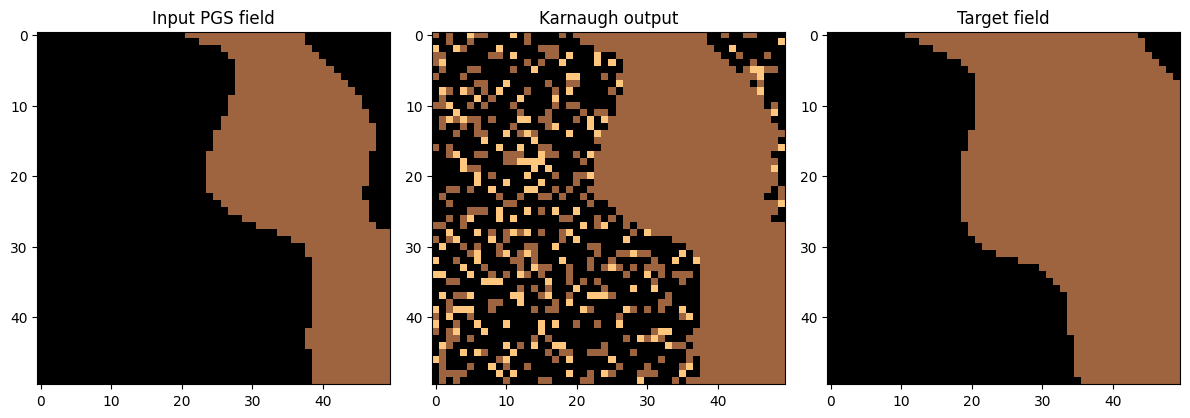

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cmap = 'copper'

axes[0].imshow(pairs[0][0], cmap=cmap, vmin=0, vmax=2)
axes[0].set_title('Input PGS field')

axes[1].imshow(result, cmap=cmap, vmin=0, vmax=2)
axes[1].set_title('Karnaugh output')

axes[2].imshow(pairs[0][1], cmap=cmap, vmin=0, vmax=2)
axes[2].set_title('Target field')

plt.tight_layout()
plt.show()